### Import all the files 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


### load all the data from the interactions.csv file 

In [2]:
df = pd.read_csv("/home/pranav/Epoch/Spring_Camp/Epoch_Spring_Camp/Recommendation_system/interactions.csv")
print(df)

       user_id  item_id
0            0        0
1            1        1
2            2        2
3            3        3
4            4        4
...        ...      ...
55370      423       53
55371      485      855
55372      801      333
55373      662      853
55374      700      151

[55375 rows x 2 columns]


### we need the number of unique user_id and item_id in the list to assign them with emmendings and also check if the ids start with 0 as embeddings index start from 0 

In [3]:
#checking the min value to see if it starts with 0
print(df['user_id'].min())
print(df['item_id'].min())

#check for any nulls 
print(df.isnull().sum())

#to see the number of unique ids 
num_user = df['user_id'].nunique()
num_items = df['item_id'].nunique()
print (num_user)
print(num_items)


0
0
user_id    0
item_id    0
dtype: int64
942
1447


### next we need to split the training data and the testing data as we have only this one interaction file .we need to do this before negative sampling otherwise out test data might get corrupt 

In [4]:
#import train_test_split function 
from sklearn.model_selection import train_test_split

# the test_size is kept 20% of the data and made it to give a fixed random state 
train_df , test_df = train_test_split(df , test_size= 0.2 , random_state= 42)
 
print(train_df)

       user_id  item_id
11911      416      474
35118      880       29
4387       283      411
29021      591      288
8615        82      264
...        ...      ...
44732       99       20
54343      923      539
38158      822      460
860        238      115
15795      201      256

[44300 rows x 2 columns]


## Negative sampling 

### Now we need to do negative sampling as our data has only the true interactions of the users but we need to have some false pairs in-order to make the model "distinguish" rather than just predict 1 for everything 

In [5]:
def negative_sample (train_df,num_neg = 1):         #default 1:1 ratio of pos and neg samples 
    # lets zip the user,item as a set so that all the repeats are removed 
    train_set = set(zip(train_df['user_id'],train_df['item_id']))
    train_labels = []
    
    for i in range(len(train_df)):
        user =df['user_id'].iloc[i]
        item = df['item_id'].iloc[i]

        #give the label 1 for the data in interation table
        train_labels.append([user,item,1])
        count = 0
        while(count<num_neg):
             

             #make a random choice 
             random_item = np.random.choice(train_df['item_id'].unique())

             if (user,random_item) not in train_set :
                 #give label 0 to the false pair
                 train_labels.append([user,random_item,0])
                 count += 1
    




    return pd.DataFrame(train_labels,columns=['user_id','item_id','label'])




## Pytorch Dataset

### we need to create the dataset so that later dataloader can access it to work on the batching process

In [6]:
class InteractionDataset (Dataset):
    def __init__(self,train_labels):
        super().__init__() 
        self.user = torch.tensor(train_labels['user_id'].values)
        self.item = torch.tensor(train_labels['item_id'].values)

        #we need the label as a float as the BCE needs it in float
        self.label = torch.tensor(train_labels['label'].values).float()

    # return the length of the user list 
    def __len__(self):
        return len(self.user)
    
    def __getitem__(self, index):
        return self.user[index], self.item[index], self.label[index]

        

## Dataloader

In [7]:
train_data = negative_sample(train_df,2)
print(train_data)
print((train_data['label']==0).sum())

train_loader = DataLoader(InteractionDataset(train_data), batch_size=256, shuffle=True)

        user_id  item_id  label
0             0        0      1
1             0      440      0
2             0      343      0
3             1        1      1
4             1      572      0
...         ...      ...    ...
132895      413      160      0
132896      413      249      0
132897      322        4      1
132898      322      617      0
132899      322      921      0

[132900 rows x 3 columns]
88600


## Quick exploration 

In [8]:
# Interactions per user
user_counts = df['user_id'].value_counts()
print(user_counts.describe())

# Interactions per item
item_counts = df['item_id'].value_counts()
print(item_counts.describe())

count    942.000000
mean      58.784501
std       54.696664
min        3.000000
25%       19.000000
50%       39.500000
75%       80.750000
max      378.000000
Name: count, dtype: float64
count    1447.000000
mean       38.268832
std        57.956847
min         1.000000
25%         3.000000
50%        13.000000
75%        47.500000
max       501.000000
Name: count, dtype: float64


## Now lets start building the Baseline Model

### Define the MF model 

In [9]:
class MF (nn.Module):
    def __init__ (self,num_user,num_items,emb_dim=50):
        super().__init__()
        
        #create the embeddings (ie user_id = x will have an embeddings in xth row )
        self.user_emb = nn.Embedding(num_user,emb_dim)
        self.item_emb = nn.Embedding(num_items,emb_dim)

    def forward(self, user_id, item_id):
        #get the embeddings using the id
        u = self.user_emb(user_id)  
        i = self.item_emb(item_id)  

        #doing the dot product 
        dot = (u * i).sum(dim=1)

        #to get a value between 0 and 1 we apply sigmoid activation function .
        # we need a 0-1 value as i BCE will need in that way to compare with the actual 0 or 1 label(that we converted to float for same dtype)
        return torch.sigmoid(dot)

### lets define the training function 

In [10]:
def train (model , dataloader , epochs ):
    #lets move the model to device gpu 
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    #defining the optimiser to be used
    optimiser = torch.optim.Adam(model.parameters(),lr = 0.001)

    #defining the loss function 
    loss_fun = nn.BCELoss()

    #creating  a list of the losses per epoch
    losses_epochs = []
    for epoch in range(epochs) :
        
        total_loss = 0
        
        for user_id , items_id ,labels in dataloader:

            #now we run the following functions on a batch of the epoch

            #moving the batch parameters to the cuda
            user_id = user_id.to(device)
            items_id = items_id.to(device)
            labels = labels.to(device)

            # we need to zero all the accumulated gradients in previous iterations
            optimiser.zero_grad()

            #now lets get the prediction
            pred = model(user_id,items_id)     #When you call model(user, item), PyTorch internally calls model.forward(user, item) — but it also does some extra things in between like handling hooks.

            #compute the loss 
            loss = loss_fun(pred,labels)

            #compute gradient
            loss.backward()

            #optimiser 
            optimiser.step()

            total_loss += loss.item()     #loss.item() gives the loss of one batch 

            #appending the loss of a batch to the list of losses so that we may later plot a curve analyse the descent
        losses_epochs.append(total_loss)
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
    return losses_epochs
                    



## lets run and check if the model is correctly reducing the loss 

Epoch 1, Loss: 3298.6760
Epoch 2, Loss: 2983.1442
Epoch 3, Loss: 2719.7554
Epoch 4, Loss: 2464.9211
Epoch 5, Loss: 2235.8284
Epoch 6, Loss: 2029.9988
Epoch 7, Loss: 1843.4620
Epoch 8, Loss: 1673.5436
Epoch 9, Loss: 1508.4504
Epoch 10, Loss: 1358.3326
Epoch 11, Loss: 1228.8119
Epoch 12, Loss: 1113.4240
Epoch 13, Loss: 1005.4433
Epoch 14, Loss: 909.5858
Epoch 15, Loss: 824.0931
Epoch 16, Loss: 743.0664
Epoch 17, Loss: 672.6519
Epoch 18, Loss: 611.1342
Epoch 19, Loss: 555.9659
Epoch 20, Loss: 503.0770


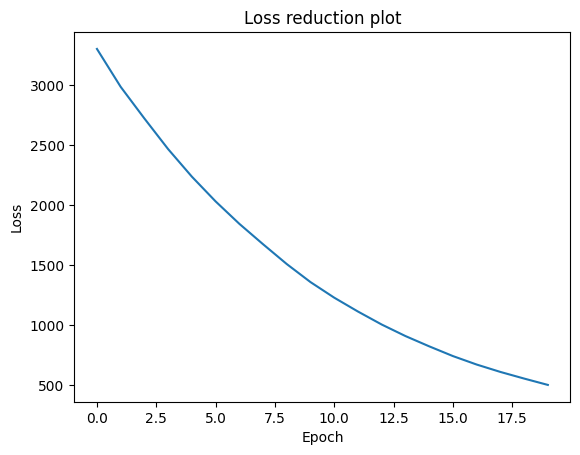

In [11]:
model = MF(num_user,num_items,100)
loss_reduction = train(model,train_loader,20)
plt.plot(loss_reduction)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss reduction plot')
plt.show()



## Now we need the Hit@K function to evaluate the model

In [ ]:
def hit_at_k(model, test_df, full_df, K=10, num_neg=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    hits = 0
    total = len(test_df) # We evaluate every positive interaction in the test set

    # Map interactions for quick lookup
    interacted_items = full_df.groupby('user_id')['item_id'].apply(set).to_dict()
    all_items = full_df['item_id'].unique()

    with torch.no_grad(): # Disable gradient calculation for speed/memory
        for _, row in test_df.iterrows():
            u = int(row['user_id'])
            pos_item = int(row['item_id'])

            # 1. Sample Negatives
            negatives = []
            while len(negatives) < num_neg:
                neg_item = np.random.choice(all_items)
                if neg_item not in interacted_items.get(u, set()):
                    negatives.append(neg_item)

            # 2. Prepare Tensors
            # We need a list of the 1 positive + 100 negatives
            item_list = [pos_item] + negatives
            user_tensor = torch.tensor([u] * (num_neg + 1)).to(device)
            item_tensor = torch.tensor(item_list).to(device)

            # 3. Get Scores
            scores = model(user_tensor, item_tensor)

            # 4. Rank and Check Hit
            # We want to see if the item at index 0 (the positive) is in the top K
            # torch.topk returns values and indices of the highest scores
            _, top_indices = torch.topk(scores, K)

            top_indices = top_indices.cpu().numpy()
            if 0 in top_indices:
                hits += 1

    return hits / total


In [13]:
hit_at_k_score = hit_at_k(model,test_df,df)
print(hit_at_k_score)

0.14609480812641085


# MLP model 

### lets us first define the MLP model 

In [14]:
class MLP (nn.Module):
    def __init__(self, num_user , num_items , emb_dim = 50):
        super().__init__()
        #give the embeddings to the batches
        self.user_emb = nn.Embedding(num_user,emb_dim)
        self.items_emb = nn.Embedding(num_items, emb_dim)

        #define the layers of the MLP and the activations to be used 
        self.layer1 = nn.Linear(2*emb_dim,emb_dim,bias=True)
        self.layer2 = nn.Linear(emb_dim,emb_dim//2)
        self.layer3 = nn.Linear(emb_dim//2,1)
        self.function1 = nn.ReLU()
        self.function2 = nn.Sigmoid()

    def forward (self, user_id , items_id):
        #call the embeddings to the tensor and concatenate the user and item together 
        u = self.user_emb(user_id)
        i = self.items_emb(items_id)
        concat =torch.cat([u,i],dim = 1)

        #implement the layers  with Relu() in the mid layers and Sigmoid() in the last to get a probability value btw 0 and 1 to pass to BCE 
        layer1 = self.layer1(concat)
        layer1_activation = self.function1(layer1)

        layer2 = self.layer2(layer1_activation)
        layer2_activation = self.function1(layer2)

        layer3 = self.layer3(layer2_activation)
        layer3_activation = self.function2(layer3).squeeze()       #the function was returning a (batch_size,1) tensor but we need (batch_size,) tensor for BCE

        return layer3_activation







### Now lets train and evaluate it 

Epoch 1, Loss: 277.4439
Epoch 2, Loss: 236.0682
Epoch 3, Loss: 228.4152
Epoch 4, Loss: 222.5622
Epoch 5, Loss: 216.9063
Epoch 6, Loss: 210.5907
Epoch 7, Loss: 203.2974
Epoch 8, Loss: 194.6682
Epoch 9, Loss: 185.1187
Epoch 10, Loss: 175.0298
Epoch 11, Loss: 164.7728
Epoch 12, Loss: 154.6549
Epoch 13, Loss: 144.3986
Epoch 14, Loss: 134.7974
Epoch 15, Loss: 125.2078
Epoch 16, Loss: 116.7829
Epoch 17, Loss: 108.2089
Epoch 18, Loss: 100.1100
Epoch 19, Loss: 92.5736
Epoch 20, Loss: 86.0650


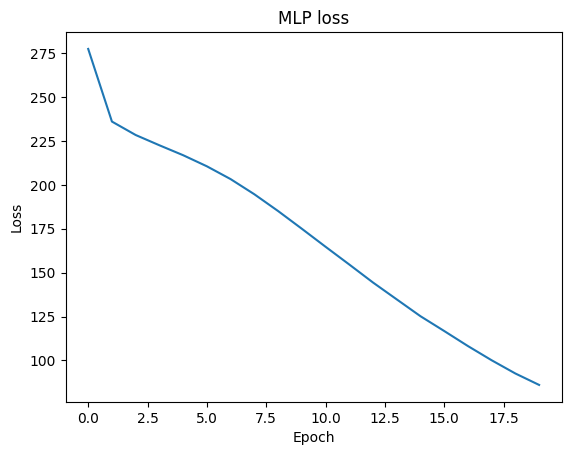

In [15]:
model_mlp = MLP(num_user,num_items,100)
loss_reduction_mlp = train(model_mlp,train_loader,20)
plt.plot(loss_reduction_mlp)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP loss')
plt.show()

### lets check the hit_at_k score 

In [16]:
hit_at_k_mlp = hit_at_k(model_mlp,test_df,df)
print(hit_at_k_mlp)

0.5963882618510158


# NeuMP


### now lets build a model that combines both the previous models to give its decision 

In [17]:
class NeuMF (nn.Module):
    def __init__ (self,num_user,num_items,emb_dim=50):
        super().__init__()

        #defining the MF embeddings 
        self.user_emb_MF = nn.Embedding(num_user,emb_dim)
        self.items_emb_MF = nn.Embedding(num_items,emb_dim)
        
        #defining the MLP embeddings 
        self.user_emb_MLP = nn.Embedding(num_user,emb_dim)
        self.items_emb_MLP = nn.Embedding(num_items,emb_dim)

        self.layer1 = nn.Linear(2*emb_dim,emb_dim,bias=True)
        self.layer2 = nn.Linear(emb_dim,emb_dim//2)
        self.layer3 = nn.Linear(emb_dim//2,1)
        self.layer4 = nn.Linear(2,1)
        self.function1 = nn.ReLU()
        self.function2 = nn.Sigmoid() 

    def forward (self,user_id,items_id):
        #performing the forward for MF
        u = self.user_emb_MF(user_id)
        i = self.items_emb_MF(items_id)

        dot = (u*i).sum(dim = 1)                            #(batch_size,)

        #performing the forward for MLP
        u = self.user_emb_MLP(user_id)                          #(batch_size,emb_dim)
        i = self.items_emb_MLP(items_id)
        concat =torch.cat([u,i],dim = 1)                    #(batch_size,2*emb_dim)

        layer1 = self.layer1(concat)                        #(256,50)
        layer1_activation = self.function1(layer1)          

        layer2 = self.layer2(layer1_activation)             #(256,25)
        layer2_activation = self.function1(layer2)

        layer3 = self.layer3(layer2_activation).squeeze()   #(256,1) squeezed to (256,)
        
        concat_MF_MLP = torch.stack([dot,layer3],dim = 1)   #(256,2)
        layer4 = self.layer4(concat_MF_MLP).squeeze()       #(256,1) => (256,)

        return self.function2(layer4) 



        
        


### lets test the model 

Epoch 1, Loss: 418.8940
Epoch 2, Loss: 239.5744
Epoch 3, Loss: 230.7981
Epoch 4, Loss: 225.2570
Epoch 5, Loss: 220.6398
Epoch 6, Loss: 214.7310
Epoch 7, Loss: 208.0136
Epoch 8, Loss: 200.0542
Epoch 9, Loss: 191.1157
Epoch 10, Loss: 180.9809
Epoch 11, Loss: 169.4986
Epoch 12, Loss: 156.6467
Epoch 13, Loss: 142.5995
Epoch 14, Loss: 127.9105
Epoch 15, Loss: 113.0821
Epoch 16, Loss: 98.8611
Epoch 17, Loss: 85.2075
Epoch 18, Loss: 72.3312
Epoch 19, Loss: 61.6089
Epoch 20, Loss: 52.6891


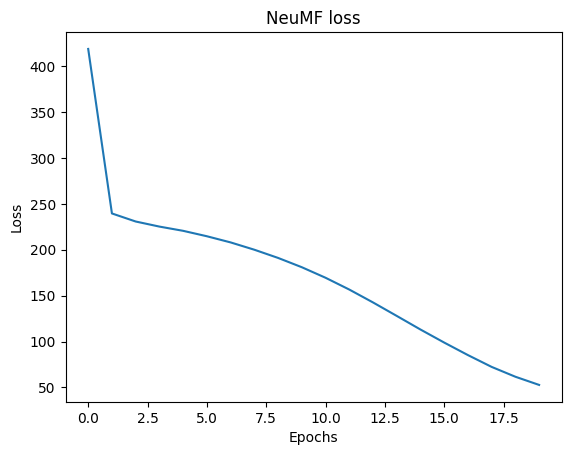

In [18]:
model_NeuMF = NeuMF(num_user,num_items,100)
loss_reduction_NeuMF = train(model_NeuMF,train_loader,20)
plt.plot(loss_reduction_NeuMF)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('NeuMF loss')
plt.show()

In [19]:
hit_at_k_NeuMF = hit_at_k(model_NeuMF,test_df,df)
print(hit_at_k_NeuMF)

0.6147178329571106
